# Employee Attrition — EDA & Data Cleaning

Dataset: IBM HR Analytics Employee Attrition (1470 rows, 35 cols).
Target: `Attrition` (Yes / No).

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [2]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
df.shape

(1470, 35)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [5]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

## Data Cleaning

From `df.nunique()` above:
- `EmployeeCount` = always 1
- `Over18` = always 'Y'
- `StandardHours` = always 80
- `EmployeeNumber` = unique per row (just an ID)

All four carry no signal — drop them.

In [8]:
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print('Constant columns:', constant_cols)

cols_to_drop = constant_cols + ['EmployeeNumber']
df = df.drop(columns=cols_to_drop)
print('New shape:', df.shape)

Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']
New shape: (1470, 31)


### Range validation
Sanity-check numeric ranges (Age > 18, YearsAtCompany >= 0, MonthlyIncome > 0).

In [9]:
print('Age           min:', df['Age'].min(),           '| max:', df['Age'].max())
print('YearsAtCompany min:', df['YearsAtCompany'].min(), '| max:', df['YearsAtCompany'].max())
print('MonthlyIncome  min:', df['MonthlyIncome'].min(),  '| max:', df['MonthlyIncome'].max())

bad_age    = (df['Age'] < 18).sum()
bad_tenure = (df['YearsAtCompany'] < 0).sum()
bad_income = (df['MonthlyIncome'] <= 0).sum()
print(f'\nRows violating ranges -> age<18: {bad_age}, tenure<0: {bad_tenure}, income<=0: {bad_income}')

Age           min: 18 | max: 60
YearsAtCompany min: 0 | max: 40
MonthlyIncome  min: 1009 | max: 19999

Rows violating ranges -> age<18: 0, tenure<0: 0, income<=0: 0


### Logical consistency
Tenure cannot exceed total working years, and cannot exceed `Age - 18`.

In [10]:
bad1 = (df['YearsAtCompany'] > df['TotalWorkingYears']).sum()
bad2 = (df['YearsAtCompany'] > (df['Age'] - 18)).sum()
bad3 = (df['YearsInCurrentRole'] > df['YearsAtCompany']).sum()
bad4 = (df['YearsWithCurrManager'] > df['YearsAtCompany']).sum()

print('YearsAtCompany > TotalWorkingYears :', bad1)
print('YearsAtCompany > (Age - 18)        :', bad2)
print('YearsInCurrentRole > YearsAtCompany:', bad3)
print('YearsWithCurrManager > YearsAtCompany:', bad4)

YearsAtCompany > TotalWorkingYears : 0
YearsAtCompany > (Age - 18)        : 0
YearsInCurrentRole > YearsAtCompany: 0
YearsWithCurrManager > YearsAtCompany: 0


## Phase 2 — Exploratory Data Analysis

### Target balance
Classification baseline — how imbalanced is `Attrition`?

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Proportions:
Attrition
No     0.839
Yes    0.161
Name: proportion, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_20580\3494993974.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, palette=['#2ecc71', '#e74c3c'])


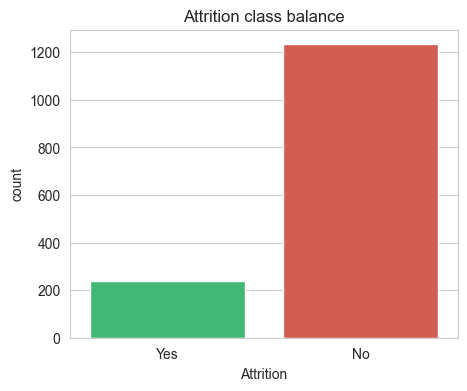

In [11]:
print(df['Attrition'].value_counts())
print('\nProportions:')
print(df['Attrition'].value_counts(normalize=True).round(3))

plt.figure(figsize=(5, 4))
sns.countplot(x='Attrition', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Attrition class balance')
plt.show()

### Numerical distributions & outliers

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.00,4.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.00,19999.0


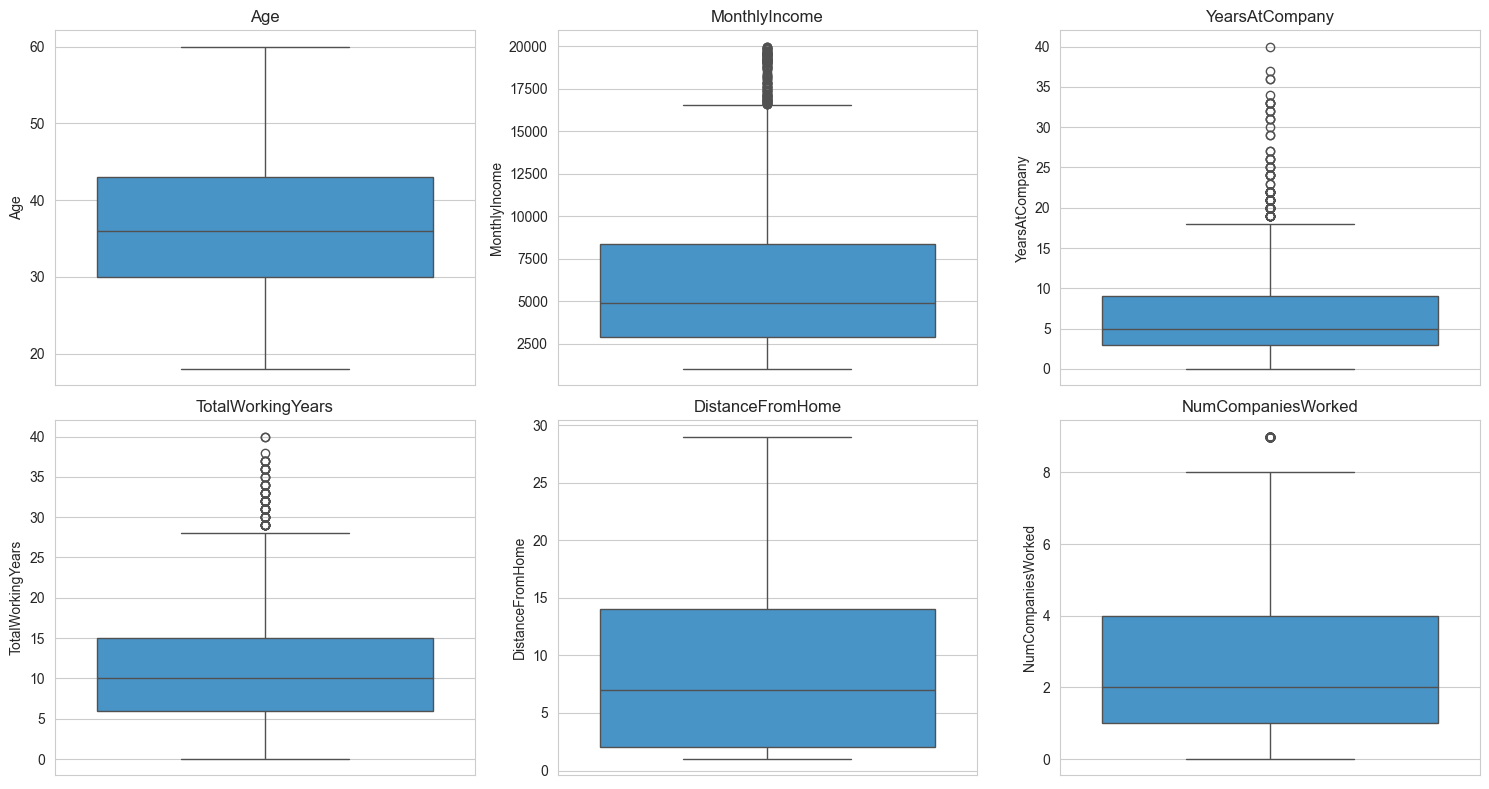

In [13]:
num_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany',
            'TotalWorkingYears', 'DistanceFromHome', 'NumCompaniesWorked']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[col], ax=ax, color='#3498db')
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Categorical sanity check
Look for typos / inconsistent casing.

In [14]:
for c in df.select_dtypes(include='object').columns:
    print(f'{c:20s} -> {df[c].unique()}')

Attrition            -> <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
BusinessTravel       -> <ArrowStringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str
Department           -> <ArrowStringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str
EducationField       -> <ArrowStringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str
Gender               -> <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
JobRole              -> <ArrowStringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Resources']
Length: 9, dtype: str
MaritalStatus        -> <ArrowStringArray>
['Single', 'Married', 'Divorced']
Leng

C:\Users\DELL\AppData\Local\Temp\ipykernel_20580\989584980.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include='object').columns:


### Attrition by Department & JobRole

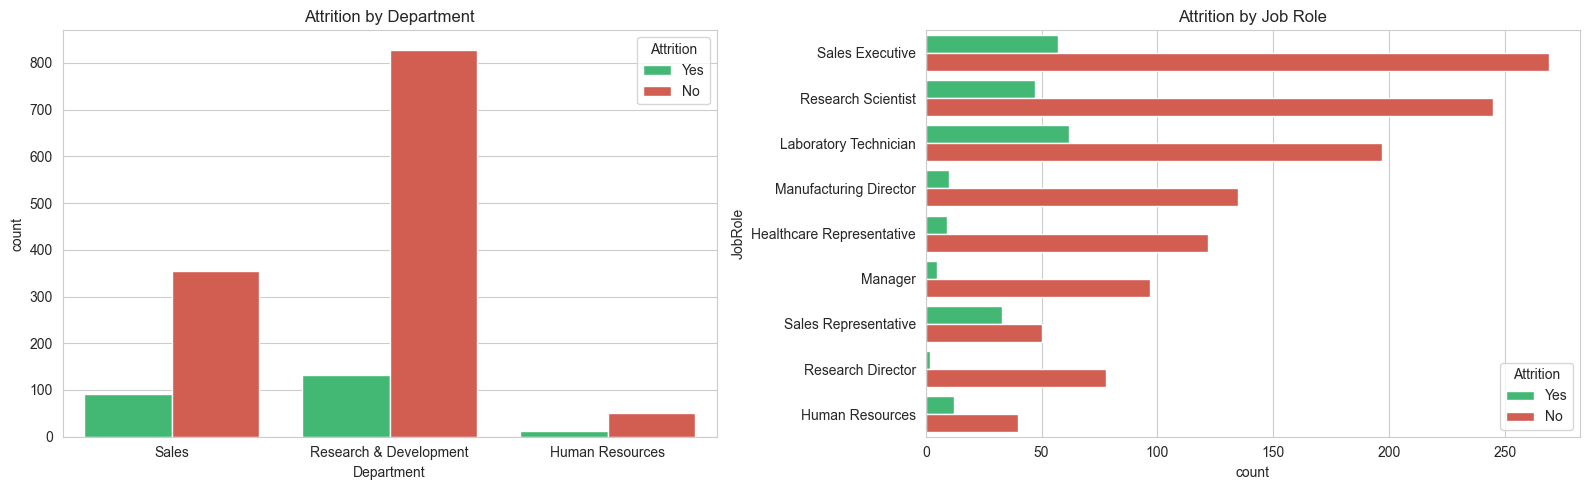

Attrition rate by department:
 Department
Human Resources           0.190
Research & Development    0.138
Sales                     0.206
Name: Attrition, dtype: float64


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(x='Department', hue='Attrition', data=df,
              palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Attrition by Department')

sns.countplot(y='JobRole', hue='Attrition', data=df,
              palette=['#2ecc71', '#e74c3c'], ax=axes[1],
              order=df['JobRole'].value_counts().index)
axes[1].set_title('Attrition by Job Role')

plt.tight_layout()
plt.show()

# attrition rate per department
rate = df.groupby('Department')['Attrition'].apply(lambda x: (x == 'Yes').mean()).round(3)
print('Attrition rate by department:\n', rate)

### Attrition by Age & MonthlyIncome

C:\Users\DELL\AppData\Local\Temp\ipykernel_20580\46756380.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df,


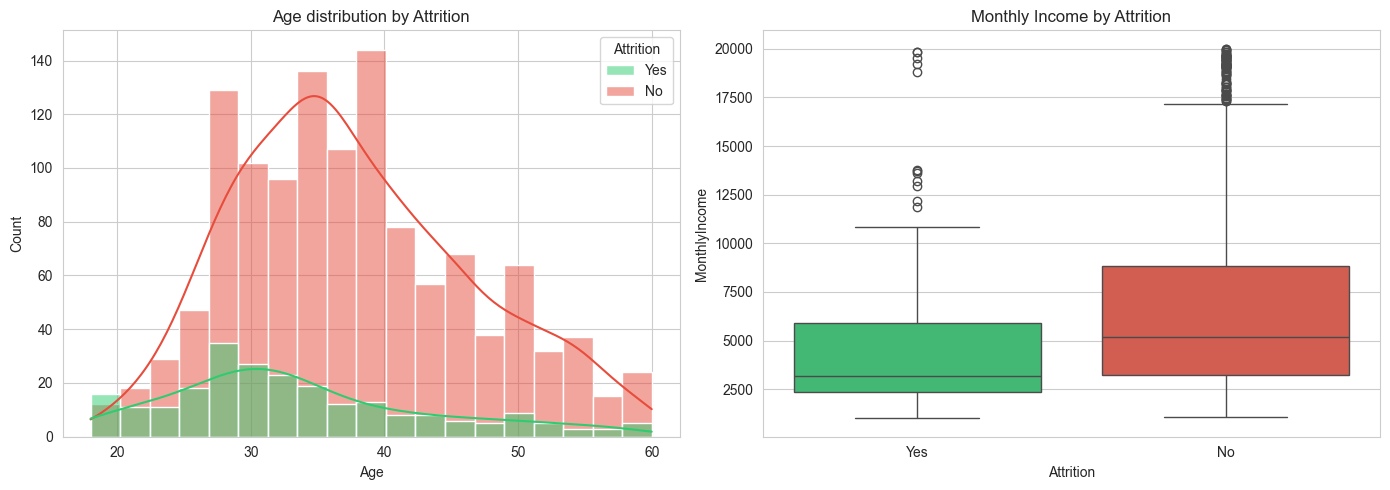

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='Age', hue='Attrition', kde=True,
             palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Age distribution by Attrition')

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df,
            palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Monthly Income by Attrition')

plt.tight_layout()
plt.show()

### Attrition by OverTime, JobSatisfaction & WorkLifeBalance

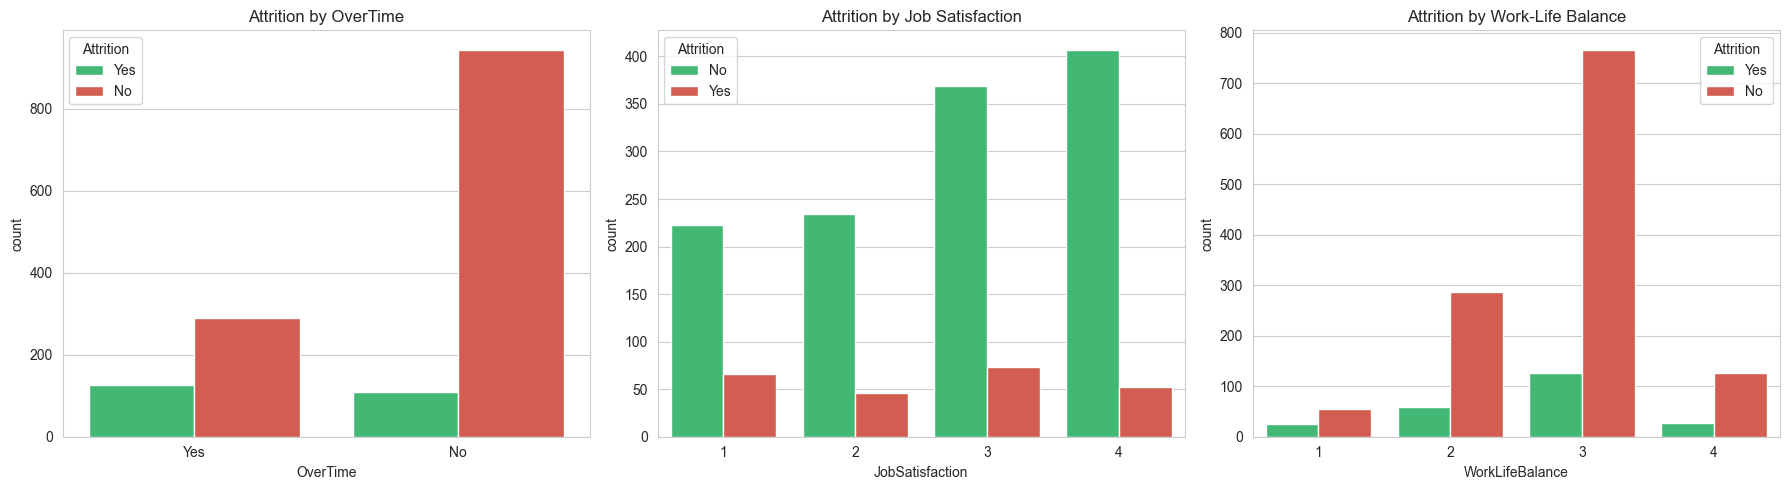

Attrition rate by OverTime:
 OverTime
No     0.104
Yes    0.305
Name: Attrition, dtype: float64


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='OverTime', hue='Attrition', data=df,
              palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Attrition by OverTime')

sns.countplot(x='JobSatisfaction', hue='Attrition', data=df,
              palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Attrition by Job Satisfaction')

sns.countplot(x='WorkLifeBalance', hue='Attrition', data=df,
              palette=['#2ecc71', '#e74c3c'], ax=axes[2])
axes[2].set_title('Attrition by Work-Life Balance')

plt.tight_layout()
plt.show()

# attrition rate by overtime
ot_rate = df.groupby('OverTime')['Attrition'].apply(lambda x: (x == 'Yes').mean()).round(3)
print('Attrition rate by OverTime:\n', ot_rate)

### Correlation heatmap (numerical features)

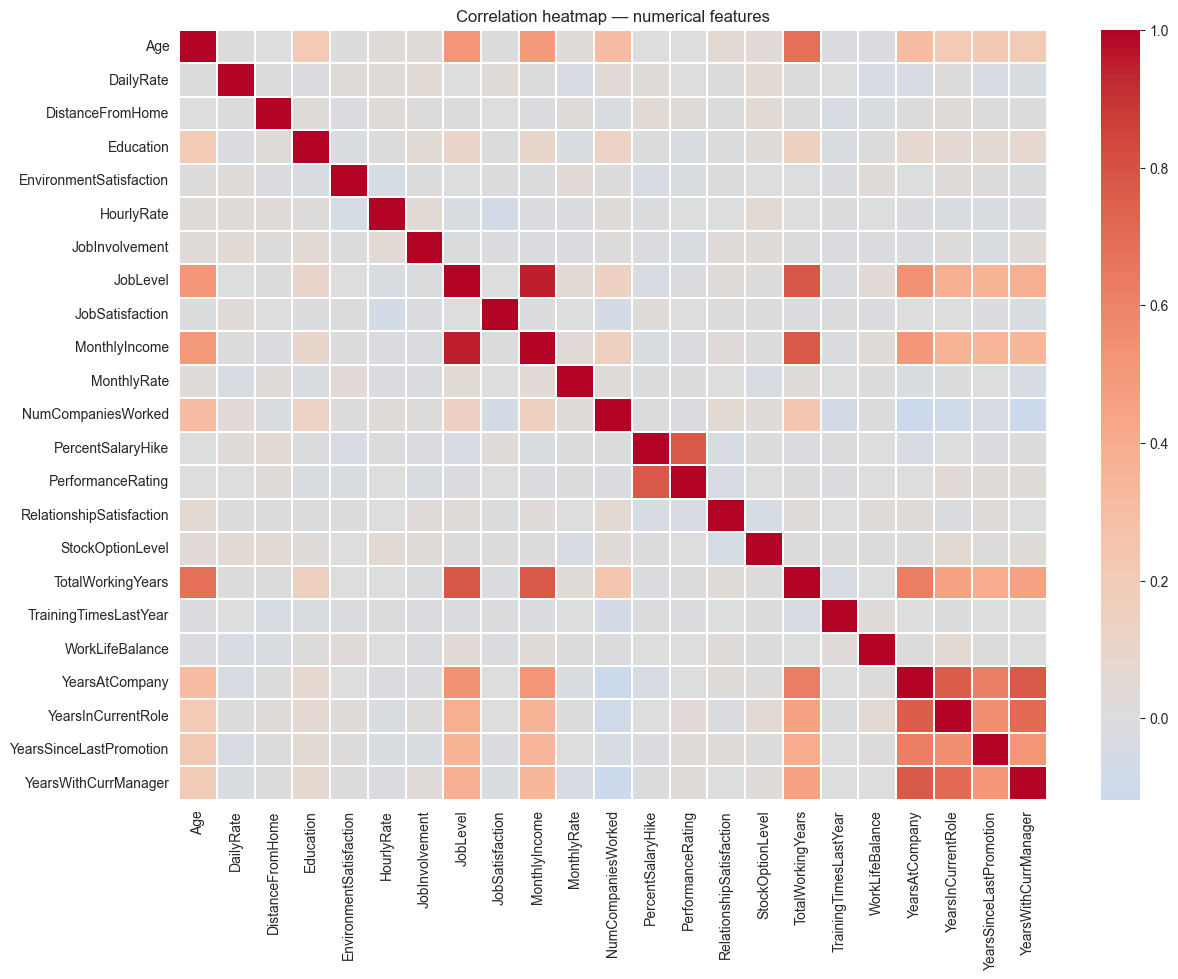

In [18]:
df_num = df.select_dtypes(include=np.number)

plt.figure(figsize=(14, 10))
sns.heatmap(df_num.corr(), cmap='coolwarm', center=0,
            annot=False, linewidths=0.3)
plt.title('Correlation heatmap — numerical features')
plt.show()

## Key Takeaways

- **No missing values, no duplicates.**
- Dropped 4 useless columns (3 constants + 1 ID).
- Target is **imbalanced** (~84% No / 16% Yes) — handle with `class_weight='balanced'` or SMOTE in Phase 6.
- Strong attrition signals: **OverTime = Yes**, **low JobSatisfaction**, **low MonthlyIncome**, **younger employees**, **Sales department**.
- Several tenure features are highly correlated (`YearsAtCompany` / `YearsInCurrentRole` / `YearsWithCurrManager`) — keep in mind for Logistic Regression (multicollinearity).
- Cleaning logic finalized in `src/data_cleaning.py`.